<a href="https://colab.research.google.com/github/Mahn17/PLN/blob/main/AC10_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Manuel Heredia - Luis Mario Sainz

<h1>Actividad en clase: Topic Modeling</h1>

In [ ]:
!gdown 1mE4dVNVqS1Xt28xz7ngHZrtGM0WTSrQ0

Downloading...
From: https://drive.google.com/uc?id=1mE4dVNVqS1Xt28xz7ngHZrtGM0WTSrQ0
To: /content/noticias_unison.csv
100% 17.3M/17.3M [00:00<00:00, 146MB/s]


In [ ]:
import pandas as pd

df = pd.read_csv('noticias_unison.csv')
df = df[['titulo','texto']]
df

,titulo,texto
0,Hay que imprimir un alto espíritu competitivo ...,Es fundamental que a todo protagonista de cual...
1,Académico de la URS ingresa al Sistema Naciona...,"Como resultado del esfuerzo, perseverancia y l..."
2,Búhos Todo Terreno apoyará a Centros Comunitar...,Con el objetivo de continuar con la vinculació...
3,Buscará el Comité de Sustentabilidad de la URS...,Para lograr mejores resultados respecto al cui...
4,Estudiantes del Campus Cajeme participaron en ...,Alrededor de 50 estudiantes de los distintos p...
...,...,...
4230,Anuncia el grupo de Altas Energías del Difus e...,El próximo sábado el grupo de Altas Energías d...
4231,Participan alumnos del campus Caborca en conve...,"En el marco del Día Internacional de la Mujer,..."
4232,Maricielo Correa: desde Perú hasta la Universi...,Maricielo Correa Carrión llegó de Perú hace do...
4233,Realizan estudiantes la Ruta de la Sororidad c...,A través de la modalidad de conversatorio y en...


Entrena un modelo de topic modeling para encontrar los tópicos principales en las noticias del sitio web de la unison.

Utiliza dos estrategias:
* Clustering con representaciones doc2vec
* LSA

En ambos casos describe cada uno de los tópicos que hayas encontrado. En el primer caso, usa una nube de palabras por cada tópico. En el segundo, infiere el tópico a partir de las principales palabras de cada tópico.

## Clustering

In [27]:
!pip install pandas nltk gensim scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 17.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Entrenando doc2vec...
Iniciando Clustering...
Generando nube de palabras por tópico...


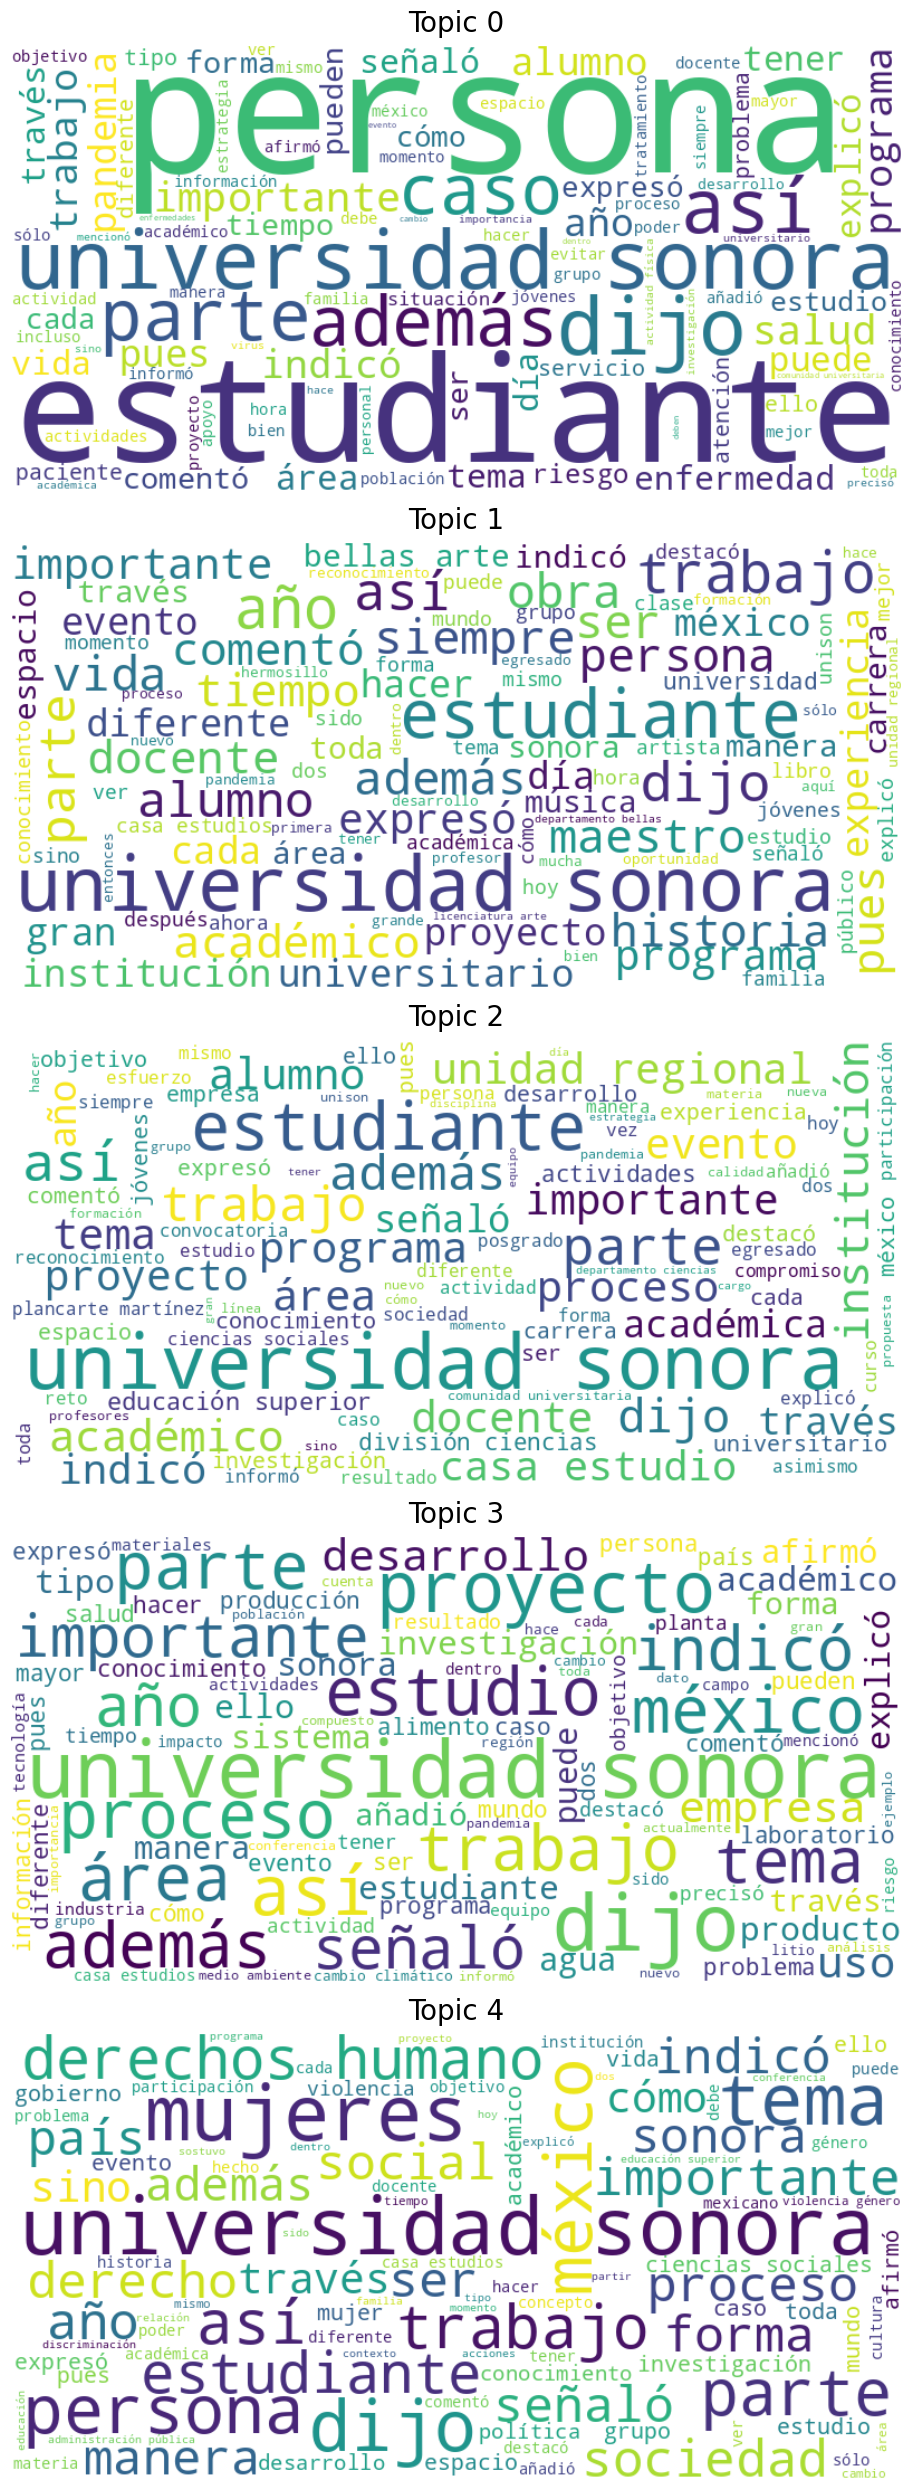

In [28]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.cluster import KMeans
from collections import Counter
import warnings
import matplotlib.pyplot as plt
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

nltk.download('punkt_tab')
nltk.download('stopwords')

df = pd.read_csv('/content/noticias_unison.csv')
df = df.dropna(subset=['texto']).reset_index(drop=True)

stop_words = set(stopwords.words('spanish'))

def preprocess_text(text):
  if not isinstance(text, str):
    return []

  tokens = word_tokenize(text.lower())
  clean_tokens = [
      word for word in tokens
      if word.isalpha() and word not in stop_words and len(word) > 2
  ]
  return clean_tokens

df['texto_procesado'] = df['texto'].apply(preprocess_text)

print("Entrenando doc2vec...")
tagged_data = [
    TaggedDocument(words=row['texto_procesado'], tags=[str(i)])
    for i, row in df.iterrows()
]

model = Doc2Vec(vector_size=50, window=5, min_count=5, workers=4, epochs=20)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

print("Iniciando Clustering...")
doc_vectors = [model.dv[str(i)] for i in range(len(df))]

num_topics = 5
kmeans_model = KMeans(n_clusters=num_topics, random_state=42, n_init=10)
kmeans_model.fit(doc_vectors)

df['cluster'] = kmeans_model.labels_

print("Generando nube de palabras por tópico...")
topics = {i: [] for i in range(num_topics)}

for i, row in df.iterrows():
    topics[row['cluster']].extend(row['texto_procesado'])

fig, axes = plt.subplots(num_topics, 1, figsize=(10, 5 * num_topics))

if num_topics == 1:
    axes = [axes]

for cluster_id, words in topics.items():
  cluster_text = " ".join(words)

  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap='viridis',
      max_words=100
  ).generate(cluster_text)

  ax = axes[cluster_id]
  ax.imshow(wordcloud, interpolation='bilinear')
  ax.set_title(f'Topic {cluster_id}', fontsize=20, pad=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

## LSA

##Procesamiento de texto



In [25]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [26]:
spanish_stopwords = stopwords.words('spanish')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercasing
    text = text.lower()
    # Quitar puntuacion y numeros
    text = re.sub(r'[^a-zñáéíóúü\s]', '', text) # Dejar acentos
    # Tokenizacion
    tokens = nltk.word_tokenize(text, language='spanish')
    # quitar stopwords y lematizar
    processed_tokens = []
    for word in tokens:
        if word not in spanish_stopwords:
            processed_tokens.append(lemmatizer.lemmatize(word))
    return ' '.join(processed_tokens)


In [ ]:
df['cleaned_text'] = df['texto'].apply(preprocess_text)
df.head()

,titulo,texto,cleaned_text
0,Hay que imprimir un alto espíritu competitivo ...,Es fundamental que a todo protagonista de cual...,fundamental protagonista cualquier disciplina ...
1,Académico de la URS ingresa al Sistema Naciona...,"Como resultado del esfuerzo, perseverancia y l...",resultado esfuerzo perseverancia alta producti...
2,Búhos Todo Terreno apoyará a Centros Comunitar...,Con el objetivo de continuar con la vinculació...,objetivo continuar vinculación universidad son...
3,Buscará el Comité de Sustentabilidad de la URS...,Para lograr mejores resultados respecto al cui...,lograr mejores resultados respecto cuidado med...
4,Estudiantes del Campus Cajeme participaron en ...,Alrededor de 50 estudiantes de los distintos p...,alrededor estudiantes distintos programas depa...


## TF-IDF Vectorizacion



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])

print("Forma de la matriz TF-IDF:")
print(tfidf_matrix.shape)

Forma de la matriz TF-IDF:
(4235, 53744)


## Modelo LSA



In [ ]:
from sklearn.decomposition import TruncatedSVD

In [21]:
n_components = 10
lsa_model = TruncatedSVD(n_components=n_components,
                         random_state=122)
lsa_topic_matrix = lsa_model.fit_transform(tfidf_matrix)

print(f"Froma de la matriz LSA: {lsa_topic_matrix.shape}")

Froma de la matriz LSA: (4235, 10)


In [24]:
# Obtiene el vocabulario del vectorizer como array (cada índice corresponde a una columna de la matriz BOW)
terms = vectorizer.get_feature_names_out()

# Itera sobre cada tópico (fila de components_), i es el número de tópico, comp es el vector de pesos
for i, comp in enumerate(lsa_model.components_):
    # Empareja cada palabra con su peso en este tópico → lista de tuplas (palabra, peso)
    terms_comp = zip(terms, comp)
    # Ordena por peso descendente y se queda con las 10 palabras más representativas del tópico
    sorted_terms = sorted(terms_comp, key= lambda x:x[1], reverse=True)[:10]
    print(f"Topic {str(i)}: ")
    # Imprime solo el nombre de la palabra (t[0]) de cada tupla
    for t in sorted_terms:
        print(t[0],end=',')
    print('\n'+75*'=')

Topic 0: 
universidad,estudiantes,sonora,ciencias,salud,programa,investigación,educación,departamento,trabajo,
Topic 1: 
mujeres,género,violencia,derechos,mujer,persona,igualdad,hombre,derecho,humanos,
Topic 2: 
salud,persona,alimentos,enfermedades,física,si,cáncer,enfermedad,enfermería,puede,
Topic 3: 
investigación,desarrollo,posgrado,ciencia,investigadores,nacional,maestría,méxico,proyectos,tecnología,
Topic 4: 
salud,campus,enfermería,servicios,unidad,programas,atención,ciencias,regional,universitaria,
Topic 5: 
física,salud,género,investigación,mujeres,violencia,deporte,matemáticas,ciencias,programa,
Topic 6: 
educación,discapacidad,deporte,superior,social,derecho,inclusión,derechos,física,estudiantes,
Topic 7: 
deporte,física,salud,maría,plancarte,rectora,cáncer,martínez,ruiz,actividad,
Topic 8: 
educación,física,deporte,superior,evaluación,acreditación,institución,discapacidad,mujeres,proceso,
Topic 9: 
deporte,física,matemáticas,ciencias,carrera,educación,actividad,psicología,m

1. ¿Qué tópicos hay?

*   Salud: Programas estudiantiles, servicios en campus, enfermedades y extensión comunitaria.

*   Deportes y Bienestar: Actividad física, espíritu competitivo y liderazgo deportivo.

* Academia e Investigación: Logros en STEM, investigación científica, posgrados y acreditación educativa.

* Responsabilidad Social: Servicio social, inclusión, discapacidad y justicia restaurativa.

* Género y Derecho: Derechos de la mujer, estudios legales y cuestiones de género.

2. ¿Coinciden en ambas estrategias?
Sí, existe una coincidencia:

* Salud: Ambos modelos la detectan como un eje central.

* Deportes/Actividad Física: Es un tema recurrente y fuerte en ambas estrategias.

* Educación e Investigación: Ambos identifican la producción científica y académica.